<a href="https://colab.research.google.com/github/zzhining/test_analysis/blob/main/bank_marketing_data_anlaysis_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 은행 상품 마케팅 데이터 분석


---


## 프로젝트 목표
---
- Pandas, Numpy를 사용하여 주어진 데이터프레임을 가공한다.
- 데이터 시각화 기법을 적용하여 그래프를 생성하고, 의미를 해석할 수 있다.


## 프로젝트 목차
---

1. **Pandas, Numpy:**
    - **데이터 불러오기:** 데이터를 불러오고 Dataframe 구조를 확인
    - **데이터 정제:** 비어 있는 데이터 또는 쓸모 없는 데이터를 삭제
    - **데이터 결합:** 데이터 프레임 분할 및 결합
    - **데이터 변환:** 집계 데이터 생성, 피봇 테이블 생성, 구간화를 통한 파생 변수 생성 등 데이터 구조 및 형태를 변환

2. **데이터 시각화:** 변수 시각화를 통하여 분포 파악


## 데이터 출처
---
- [Bank Marketing](https://archive.ics.uci.edu/ml/datasets/bank+marketing)


## 프로젝트 개요
---

### 📌 배경 (Context)
이 데이터는 포르투갈 은행 기관의 전화 기반 직접 마케팅 캠페인과 관련된 것으로 **고객이 정기예금에 가입할지를 예측**하는 것을 목표로 한다.

### 📁 데이터 설명 (Content)
마케팅 캠페인은 전화 통화를 통해 이루어졌으며, 한 명의 고객에게 여러 차례 연락을 시도한 경우도 있다. 이 데이터셋은 고객이 정기예금 상품에 가입할지(`yes`) 혹은 가입하지 않을지(`no`)를 파악하기 위한 목적으로 사용한다.

### 📊 데이터 구성 요소
✅은행 고객 데이터:
- **`Age` (나이)**: 숫자형
- **`Job` (직업 유형)**: 범주형 (`admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`)
- **`Marital` (결혼 상태)**: 범주형 (`divorced`, `married`, `single`, `unknown`; 참고: `divorced`는 이혼 혹은 사별을 의미)
- **`Education` (교육 수준)**: 범주형 (`basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`)
- **`Default` (신용불량 여부)**: 범주형 (`no`, `yes`, `unknown`)
- **`Housing` (주택담보대출 여부)**: 범주형 (`no`, `yes`, `unknown`)
- **`Loan` (개인대출 여부)**: 범주형 (`no`, `yes`, `unknown`)

✅현재 캠페인의 마지막 연락과 관련된 속성:
- **`Contact` (연락 방식)**: 범주형 (`cellular`, `telephone`)
- **`Month` (마지막 연락 월)**: 범주형 (`jan`, `feb`, `mar`, ..., `nov`, `dec`)
- **`Day_of_week` (마지막 연락 요일)**: 범주형 (`mon`, `tue`, `wed`, `thu`, `fri`)
- **`Duration` (마지막 통화 시간, 초 단위)**: 숫자형

  👉중요: 이 속성은 예측 결과에 큰 영향을 미침 (예: duration=0이면 y=`no`). 그러나 duration은 통화가 실제로 이루어지기 전에는 알 수 없다. 또한 통화가 종료된 후에는 y 값이 명확해지므로, 이 속성은 벤치마크 용도로만 포함하고 실제 예측 모델에는 제외하는 것이 적절하다.

✅기타 속성:
- **`Campaign`**: 현재 캠페인 동안 해당 고객에게 이루어진 연락 횟수 (숫자형, 마지막 연락 포함)
- **`Pdays`**: 이전 캠페인에서 마지막으로 고객에게 연락한 이후 경과 일수 (숫자형; 999는 이전 연락이 없었음을 의미)
- **`Previous`**: 이전 캠페인에서 고객에게 이루어진 연락 횟수 (숫자형)
- **`Poutcome`**: 이전 마케팅 캠페인의 결과 (범주형: `failure`, `nonexistent`, `success`)

✅ 사회 및 경제적 맥락 속성:
- **`Emp.var.rate`**: 고용 변동률 – 분기별 지표 (숫자형)
- **`Cons.price.idx`**: 소비자 물가지수 – 월간 지표 (숫자형)
- **`Cons.conf.idx`**: 소비자 신뢰지수 – 월간 지표 (숫자형)
- **`Euribor3m`**: 3개월 유리보 금리 – 일간 지표 (숫자형)
- **`Nr.employed`**: 고용자 수 – 분기별 지표 (숫자형)

✅ 출력 변수 (예측 목표):
- **`y`**: 고객이 정기예금에 가입했는가? (이진 분류: `yes`, `no`)


## 1. Pandas, Numpy
---


### 1.1 pandas 기초
---

pandas를 사용하여 데이터를 읽고 dataframe 형태로 저장합니다.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('bank-additional-full.csv', sep = ';')
print(df.shape)
display(df.head())

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#### 1.1.1 `y`별 데이터의 수
---
`y`별 데이터의 갯수를 확인합니다.
- 데이터프레임의 `value_counts()`를 사용하면 각 범주의 수를 반환합니다.
- 인자로 `normalize=True`를 설정하면 비율을 반환합니다.

In [ ]:
display(df['y'].value_counts())
display(df['y'].value_counts(normalize=True))

,count
y,
no,36548
yes,4640


,proportion
y,
no,0.887346
yes,0.112654


- 정기예금에 가입하지 않은 고객이 36,548명, 가입한 고객이 4,640명으로 불균형한 데이터이다.
- 전체 고객 중 약 88.8%는 가입하지 않았고, 11.2%만 가입했다.
- 데이터가 불균형(imbalanced)하다.

#### 1.1.2 데이터 컬럼 별 타입 및 결측치 확인
---
데이터 프레임의 `info()`를 호출하면 컬럼 별 데이터 타입과 결측치가 아닌 데이터의 수를 확인할 수 있습니다.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

- 결측치는 존재하지 않는다.

#### 1.1.3 주요 통계지표
---
데이터 프레임의 수치형 변수에 대해, 주요 통계지표를 확인합니다.

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


- `age`: 평균 나이는 약 40세, 최소 17세, 최대 98세임. 나이 분포가 30~50대에 집중되어 있을 가능성이 높음
- `duration`: 평균 통화 시간은 약 258초, 최대 4918초(약 82분)로, 긴 통화는 일부 예외적인 케이스일 가능성이 있음.
- `campaign`: 평균 2.76회 연락됨. 최대 63회는 과도하게 연락한 경우로 이상치 가능성 있음
- `pdays` : 평균 962일로 대부분 "이전에 연락하지 않음"일 가능성이 높음. 999로 나타낸 값은 특수값이므로 별도로 처리 필요
- `previous`: 이전 캠페인에서의 연락 횟수로 대다수가 이전 연락이 없었음


⭐참고⭐

`describe(include='object')`를 호출하면, 범주형 데이터에 대한 요약을 확인할 수 있습니다.

In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


일부 컬럼(`age`, `job`)만 필터링하여 통계 지표를 확인할 수 있습니다.

⭐참고⭐

`describe(include='all')`를 호출하면, 수치형 데이터와 범주형 데이터에 대한 요약을 모두 확인할 수 있습니다.

In [ ]:
df[['age', 'job']].describe(include='all')

,age,job
count,41188.00000,41188
unique,NaN,12
top,NaN,admin.
freq,NaN,10422
mean,40.02406,NaN
std,10.42125,NaN
min,17.00000,NaN
25%,32.00000,NaN
50%,38.00000,NaN
75%,47.00000,NaN


### 1.2 데이터 정제

#### 1.2.1 결측치 처리
---
결측치의 수를 확인합니다.

In [ ]:
print(f'결측치 수:', df.isna().sum().sum())

결측치 수: 0


결측치가 존재하지 않아 결측치 처리는 수행하지 않습니다.

#### 1.2.2 이상치처리

##### Z-score 방식
 - 정규분포 가정
 - ±3 기준

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*Cy83F-x161QzuUcX2zUypQ.png)


`duration` 컬럼에 대해서 Z-score방식으로 이상치 여부를 판단하고자 합니다. 이상치를 포함하고 있는 값이 몇 개 인지 확인해보겠습니다.

In [ ]:
z = (df['duration'] - df['duration'].mean()) / df['duration'].std()
outliers = df[np.abs(z) > 3]
df.shape, outliers.shape, round(outliers.shape[0] / df.shape[0], 3)

((41188, 21), (861, 21), 0.021)

41,188개의 데이터 중에 861개가 이상치로 판별되었습니다. 이는 전체 데이터 셋의 2%에 해당하는 값입니다.

`duration`, `campaign`, `previous`, `euribor3m`, `nr.employed` 의 컬럼에 대해 z-score 방식으로 이상치 처리를 하고자 합니다. 이상치가 포함된 경우, 이상치를 제외한 가장 가까운 값(3보다 클 경우에는 가장 큰 값으로, -3보다 작을 경우에는 가장 작은 값으로) 대체합니다.

In [ ]:
# 대상 컬럼 목록
cols = ['duration', 'campaign', 'previous', 'euribor3m', 'nr.employed']

# 복사본 생성
df_processed = df.copy()

for col in cols:
    # 평균과 표준편차 계산
    mean = df_processed[col].mean()
    std = df_processed[col].std()

    # z-score 계산
    z = (df_processed[col] - mean) / std

    # 정상 범위 값 (절댓값 3 이내)
    within_range = df_processed[np.abs(z) <= 3][col]

    # 최대값 및 최소값 정의
    max_valid = within_range.max()
    min_valid = within_range.min()

    # 이상치 대체
    df_processed.loc[z > 3, col] = max_valid
    df_processed.loc[z < -3, col] = min_valid

    print(f"{col}:")
    print(f" -최대값({max_valid})으로 교체된 이상치: {sum(z > 3)}개")
    print(f" -최소값({min_valid})으로 교체된 이상치: {sum(z < -3)}개")

duration:
 -최대값(1036)으로 교체된 이상치: 861개
 -최소값(0)으로 교체된 이상치: 0개
campaign:
 -최대값(10)으로 교체된 이상치: 869개
 -최소값(1)으로 교체된 이상치: 0개
previous:
 -최대값(1)으로 교체된 이상치: 1064개
 -최소값(0)으로 교체된 이상치: 0개
euribor3m:
 -최대값(5.045)으로 교체된 이상치: 0개
 -최소값(0.634)으로 교체된 이상치: 0개
nr.employed:
 -최대값(5228.1)으로 교체된 이상치: 0개
 -최소값(4963.6)으로 교체된 이상치: 0개


##### IQR 방식 (Interquartile Range)

![](https://www.scribbr.com/wp-content/uploads/2022/01/interquartile-range.png)

`previous` 컬럼에 대해서 IQR 방식으로 이상치 여부를 판단하고자 합니다. 이상치를 포함하고 있는 값이 몇 개 인지 확인해보겠습니다.

In [ ]:
Q1 = df['previous'].quantile(0.25)
Q3 = df['previous'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['previous'] < Q1 - 1.5 * IQR) | (df['previous'] > Q3 + 1.5 * IQR)]
df.shape, outliers.shape, round(outliers.shape[0] / df.shape[0], 3)

((41188, 21), (5625, 21), 0.137)

41,188개의 데이터 중에 5625개가 이상치로 판별되었습니다. 이는 전체 데이터 셋의 13.7%에 해당하는 값입니다.

`previous`, `cons.conf.idx`, `emp.var.rate`의 컬럼에 대해 IQR 방식으로 이상치 처리를 하고자 합니다. 이상치로 판단된 컬림이 각각 몇 개인지 확인합니다.

In [ ]:
# IQR 기반 이상치 탐지 대상 컬럼
iqr_cols = ['previous', 'cons.conf.idx', 'emp.var.rate']

# 결과 저장용 딕셔너리
outlier_counts = {}

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 이상치 조건
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치 개수 계산
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()

    outlier_counts[col] = outlier_count

# 출력
for col, count in outlier_counts.items():
    print(f"{col}: 이상치 개수 = {count}")

previous: 이상치 개수 = 5625
cons.conf.idx: 이상치 개수 = 447
emp.var.rate: 이상치 개수 = 0


##### Isolation Forest
![](https://woongsonvi.github.io/images/2024-11-16-AI9/image-20241116221513060.png)


- 각 트리는 랜덤하게 선택된 변수와 분할 값을 사용해 데이터를 나눔
- 샘플이 트리 내에서 고립되기까지의 평균 깊이를 기준으로 이상치 점수를 계산

In [ ]:
from sklearn.ensemble import IsolationForest

# contamination: 전체 데이터 중 이상치가 어느 정도 존재한다고 가정할 것인지를 지정
model = IsolationForest(contamination=0.01, random_state=42)

# IsolationForest는 수치 데이터를 기반으로 작동하므로, 수치형 데이터만 학습에 사용
df['outlier_flag'] = model.fit_predict(df.select_dtypes(include='number'))
df['outlier_flag'].value_counts()

,count
outlier_flag,
1,40776
-1,412


### 1.3 데이터 분할과 결합

#### 1.3.1 데이터 분할

---
인덱스가 5의 배수인 데이터만 샘플링합니다.

In [ ]:
df_sampled = df[df.index % 5 == 0]
print(df_sampled.shape)
display(df_sampled.head())

(8238, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,outlier_flag
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
15,54,retired,married,basic.9y,unknown,yes,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
20,30,unemployed,married,high.school,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


`age`가 50보다 큰 값만 샘플링합니다.

In [ ]:
df_sampled1 = df[df['age'] > 50]
print(df_sampled1.shape)
display(df_sampled1.head())

(7180, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,outlier_flag
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
13,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


`age`가 50보다 크고, `month`가 3월인 데이터만 샘플링합니다.

In [ ]:
df_sampled2 = df[(df['age'] > 50) & (df['month'] == 'mar')]
print(df_sampled2.shape)
display(df_sampled2.head())

(132, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,outlier_flag
27713,70,retired,divorced,basic.4y,no,yes,no,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.811,5099.1,yes,1
27715,61,admin.,married,university.degree,no,yes,no,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.811,5099.1,no,1
27723,66,technician,married,professional.course,no,yes,no,cellular,mar,tue,...,999,0,nonexistent,-1.8,92.843,-50.0,1.799,5099.1,yes,1
27757,76,retired,married,university.degree,no,no,yes,cellular,mar,thu,...,999,0,nonexistent,-1.8,92.843,-50.0,1.757,5099.1,no,1
27772,55,technician,single,professional.course,no,yes,yes,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.703,5099.1,yes,1


In [ ]:
# query를 사용하는 경우
df_sampled3 = df.query("age > 50 and month == 'mar'")
print(df_sampled3.shape)
display(df_sampled3.head())

(132, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,outlier_flag
27713,70,retired,divorced,basic.4y,no,yes,no,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.811,5099.1,yes,1
27715,61,admin.,married,university.degree,no,yes,no,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.811,5099.1,no,1
27723,66,technician,married,professional.course,no,yes,no,cellular,mar,tue,...,999,0,nonexistent,-1.8,92.843,-50.0,1.799,5099.1,yes,1
27757,76,retired,married,university.degree,no,no,yes,cellular,mar,thu,...,999,0,nonexistent,-1.8,92.843,-50.0,1.757,5099.1,no,1
27772,55,technician,single,professional.course,no,yes,yes,cellular,mar,mon,...,999,0,nonexistent,-1.8,92.843,-50.0,1.703,5099.1,yes,1


다음과 같이 컬럼을 특징에 따라 [고객관련, 연락 관련, 기타, 사회 및 경제 지표]의 속성으로 나눠서 별도의 데이터 프레임으로 생성하고자 합니다.

In [ ]:
# 고객 관련 컬럼
customer_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

# 연락 관련 컬럼
campaign_cols = ['contact', 'month', 'day_of_week', 'duration', 'campaign']

# 기타 속성 컬럼
other_cols = ['pdays', 'previous', 'poutcome',
              'emp.var.rate', 'cons.price.idx',
              'cons.conf.idx', 'euribor3m', 'nr.employed']

# 사회 및 경제 지표 변수
socio_econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

In [ ]:
df_customer = df[customer_cols]
df_campaign = df[campaign_cols]
df_other = df[other_cols]
df_socio_econ = df[socio_econ_cols]

In [ ]:
df_customer.shape, df_campaign.shape, df_other.shape, df_socio_econ.shape

((41188, 7), (41188, 5), (41188, 8), (41188, 5))

#### 1.3.2 데이터 결합

위에서 생성한 개별 데이터프레임을 하나의 데이터 프레임으로 병합합니다.

In [ ]:
df_concated = pd.concat([df_customer, df_campaign, df_other, df_socio_econ], axis=1)
df_concated.shape

(41188, 25)

### 1.4 데이터 변환

#### 1.4.1 파생변수 생성
---
✍`Pdays`: 이전 캠페인에서 마지막으로 고객에게 연락한 이후 경과 일수 (숫자형; 999는 이전 연락이 없었음을 의미)

`pdays` == 999를 별도로 시각화하기 위해 파생 변수로 연락 여부('Yes', 'No')를 나타내는 신규 변수(`contacted_before`)를 생성합니다.

In [ ]:
# [TO-DO] 01. contacted_before라는 파생 변수를 생성


#### 1.4.2 집계 데이터(groupby)

이전 연락이 있었는지 여부에 따른 `y`의 값의 수를 출력합니다.

In [ ]:
# [TO-DO] 02. 이전 연락 여부(contacted_before)에 따른 집계 데이터 생성
# groupby + size를 사용하는 방법


,y
contacted_before,
No,39673
Yes,1515


In [ ]:
# [TO-DO] 03. 이전 연락 여부(contacted_before)에 따른 집계 데이터 생성
# groupby + value_counts를 사용하는 방법


contacted_before  y  
No                no     36000
                  yes     3673
Yes               yes      967
                  no       548
Name: count, dtype: int64

In [ ]:
# [TO-DO] 04. 여러 개의 컬럼을 기준으로 그룹핑


contacted_before  pdays  y  
No                999    no     36000
                         yes     3673
Yes               0      yes       10
                         no         5
                  1      no        18
                         yes        8
                  2      yes       37
                         no        24
                  3      yes      298
                         no       141
                  4      yes       63
                         no        55
                  5      yes       29
                         no        17
                  6      yes      289
                         no       123
                  7      yes       40
                         no        20
                  8      yes       12
                         no         6
                  9      yes       35
                         no        29
                  10     yes       30
                         no        22
                  11     yes       15
                         no        13
                  12     no        32
                         yes       26
                  13     yes       28
                         no         8
                  14     yes       11
                         no         9
                  15     yes       16
                         no         8
                  16     yes        6
                         no         5
                  17     no         6
                         yes        2
                  18     yes        4
                         no         3
                  19     no         2
                         yes        1
                  20     no         1
                  21     yes        2
                  22     yes        2
                         no         1
                  25     yes        1
                  26     yes        1
                  27     yes        1
Name: count, dtype: int64

In [ ]:
# [TO-DO] 05. pivot_table을 사용하는 방법


y,no,yes
contacted_before,,
No,36000,3673
Yes,548,967


In [ ]:
# pivot_table을 사용하는 방법


contacted_before       No   Yes                                              \
pdays                 999   0     1     2      3     4     5      6     7     
y                                                                             
no                36000.0   5.0  18.0  24.0  141.0  55.0  17.0  123.0  20.0   
yes                3673.0  10.0   8.0  37.0  298.0  63.0  29.0  289.0  40.0   

contacted_before        ...                                                    
pdays              8    ...  16   17   18   19   20   21   22   25   26   27   
y                       ...                                                    
no                 6.0  ...  5.0  6.0  3.0  2.0  1.0  NaN  1.0  NaN  NaN  NaN  
yes               12.0  ...  6.0  2.0  4.0  1.0  NaN  2.0  2.0  1.0  1.0  1.0  

[2 rows x 27 columns]

#### 1.4.3 집계 데이터(pivot)
---
직업(`job`)과 결혼 상태(`marital`)에 따른 평균 나이(`age`)를 피벗 테이블 형태로 출력합니다.

In [ ]:
# [TO-DO] 06. pivot_table 생성


marital,divorced,married,single,unknown
job,,,,
admin.,43.282031,40.302303,33.645935,35.785714
blue-collar,42.840659,40.889637,33.342466,41.571429
entrepreneur,44.106145,42.527544,35.492611,34.000000
housemaid,49.621118,45.745174,38.462185,40.000000
management,46.190332,43.756343,33.972056,51.000000
retired,64.456897,61.830455,55.688172,61.000000
self-employed,42.751880,42.230088,33.532982,39.400000
services,42.084586,39.876199,32.036060,40.000000
student,34.888889,30.634146,25.555825,30.000000


In [ ]:
# [TO-DO] 07. crosstab을 사용하는 방법


marital,divorced,married,single,unknown
job,,,,
admin.,1280,5253,3875,14
blue-collar,728,6687,1825,14
entrepreneur,179,1071,203,3
housemaid,161,777,119,3
management,331,2089,501,3
retired,348,1274,93,5
self-employed,133,904,379,5
services,532,2294,1137,6
student,9,41,824,1


주어진 데이터를 직업(`job`)과 결혼 상태(`marital`)에 따라 구분하여 각 조건에 알맞는 데이터의 수를 피벗 테이블 형태로 출력합니다.

In [ ]:
# aggfunc에 count를 사용
df.pivot_table(index='job', columns='marital', values='age', aggfunc='count')

marital,divorced,married,single,unknown
job,,,,
admin.,1280,5253,3875,14
blue-collar,728,6687,1825,14
entrepreneur,179,1071,203,3
housemaid,161,777,119,3
management,331,2089,501,3
retired,348,1274,93,5
self-employed,133,904,379,5
services,532,2294,1137,6
student,9,41,824,1


주어진 데이터를 직업(`job`)과 결혼 상태(`marital`)에 따라 구분하여 각 조건에 알맞는 데이터의 수를 피벗 테이블 형태로 출력합니다. 추가로, 응답의 결과(`y`)를 구분하여 출력합니다.

In [ ]:
# columns에 여러 개의 값을 지정할 수 있음, 순서에 따라 출력 결과 달라짐
df.pivot_table(index='job', columns=['y', 'marital'],
               values='age', aggfunc='count')

y                   no                              yes                       
marital       divorced married  single unknown divorced married single unknown
job                                                                           
admin.          1148.0  4601.0  3309.0    12.0    132.0   652.0  566.0     2.0
blue-collar      675.0  6266.0  1664.0    11.0     53.0   421.0  161.0     3.0
entrepreneur     165.0   983.0   182.0     2.0     14.0    88.0   21.0     1.0
housemaid        145.0   703.0   103.0     3.0     16.0    74.0   16.0     NaN
management       292.0  1863.0   438.0     3.0     39.0   226.0   63.0     NaN
retired          256.0   945.0    81.0     4.0     92.0   329.0   12.0     1.0
self-employed    117.0   822.0   328.0     5.0     16.0    82.0   51.0     NaN
services         499.0  2128.0  1013.0     6.0     33.0   166.0  124.0     NaN
student            6.0    33.0   560.0     1.0      3.0     8.0  264.0     NaN
technician       709.0  3286.0  2008.0    10.0     65.0   384.0  279.0     2.0
unemployed       114.0   548.0   203.0     5.0     10.0    86.0   48.0     NaN
unknown           10.0   218.0    59.0     6.0      3.0    16.0   15.0     3.0

#### 1.4.4 구간화
---

`Emp.var.rate`는 고용 변동률(employment variation rate)을 의미합니다. 이는 분기별 지표로 다음과 같은 고유 값을 갖습니다.

In [ ]:
df['emp.var.rate'].unique()

array([ 1.1,  1.4, -0.1, -0.2, -1.8, -2.9, -3.4, -3. , -1.7, -1.1])

고용 변동률을 아래의 표와 같이 4개의 구간으로 나눠서 분석하고자 합니다. 주어진 조건에 따라 'Severe', 'Weak', 'Stable', 'Positive'의 값을 갖는 새로운 컬럼 `emp_rate_bin`을 생성합니다.


| 구간 이름 | 값의 범위   | 해석                         |
|-----------|-------------|------------------------------|
| Positive  | > 0         | 고용 증가 (긍정적 경제 상황) |
| Stable    | 0 ~ -1.0    | 비교적 안정                  |
| Weak      | -1.0 ~ -2.5 | 고용 둔화                    |
| Severe    | < -2.5      | 심각한 경기 침체 신호        |

In [ ]:
# [TO-DO] 08. 'emp.var.rate' 구간화
# bins=[-np.inf, -2.5, -1.0, 0, np.inf],
# labels=['Severe', 'Weak', 'Stable', 'Positive']



In [ ]:
df['emp_rate_bin'].value_counts()

,count
emp_rate_bin,
Positive,23997
Weak,10592
Stable,3693
Severe,2906


`cons.price.idx`는 소비자 물가 지수 (consumer price index)를 의미합니다. 소비자 물가 지수는 전체 데이터를 4개의 분위로 나누고, 각각을 소비자 물가 수준이 낮은 순서로 정렬하여 'Q1', 'Q2', 'Q3', 'Q4'의 값을 할당하여 `cons_price_qcut` 컬럼에 저장합니다.

In [ ]:
df['cons.price.idx'].unique()

array([93.994, 94.465, 93.918, 93.444, 93.798, 93.2  , 92.756, 92.843,
       93.075, 92.893, 92.963, 92.469, 92.201, 92.379, 92.431, 92.649,
       92.713, 93.369, 93.749, 93.876, 94.055, 94.215, 94.027, 94.199,
       94.601, 94.767])

In [ ]:
# [TO-DO] 09.'cons_price_qcut' 구간화


## 2. 데이터 시각화
---


### 2.1 분포 시각화
---

<Axes: xlabel='age', ylabel='Count'>

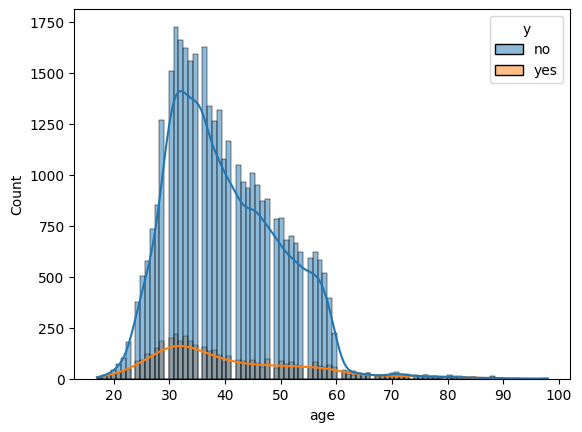

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='age', hue='y', kde=True)

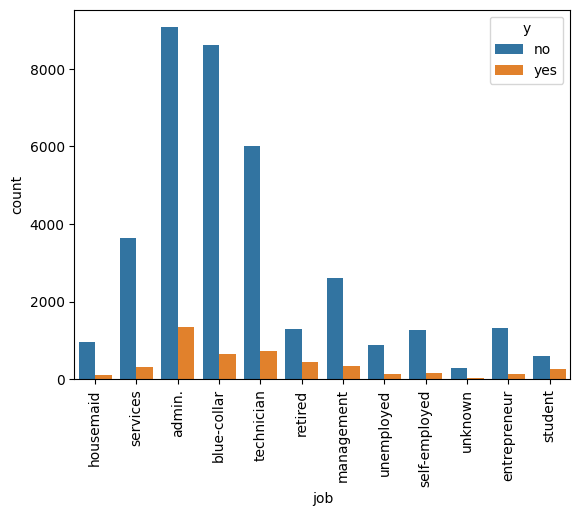

In [ ]:
sns.countplot(data=df, x='job', hue='y')
plt.xticks(rotation=90)
plt.show()

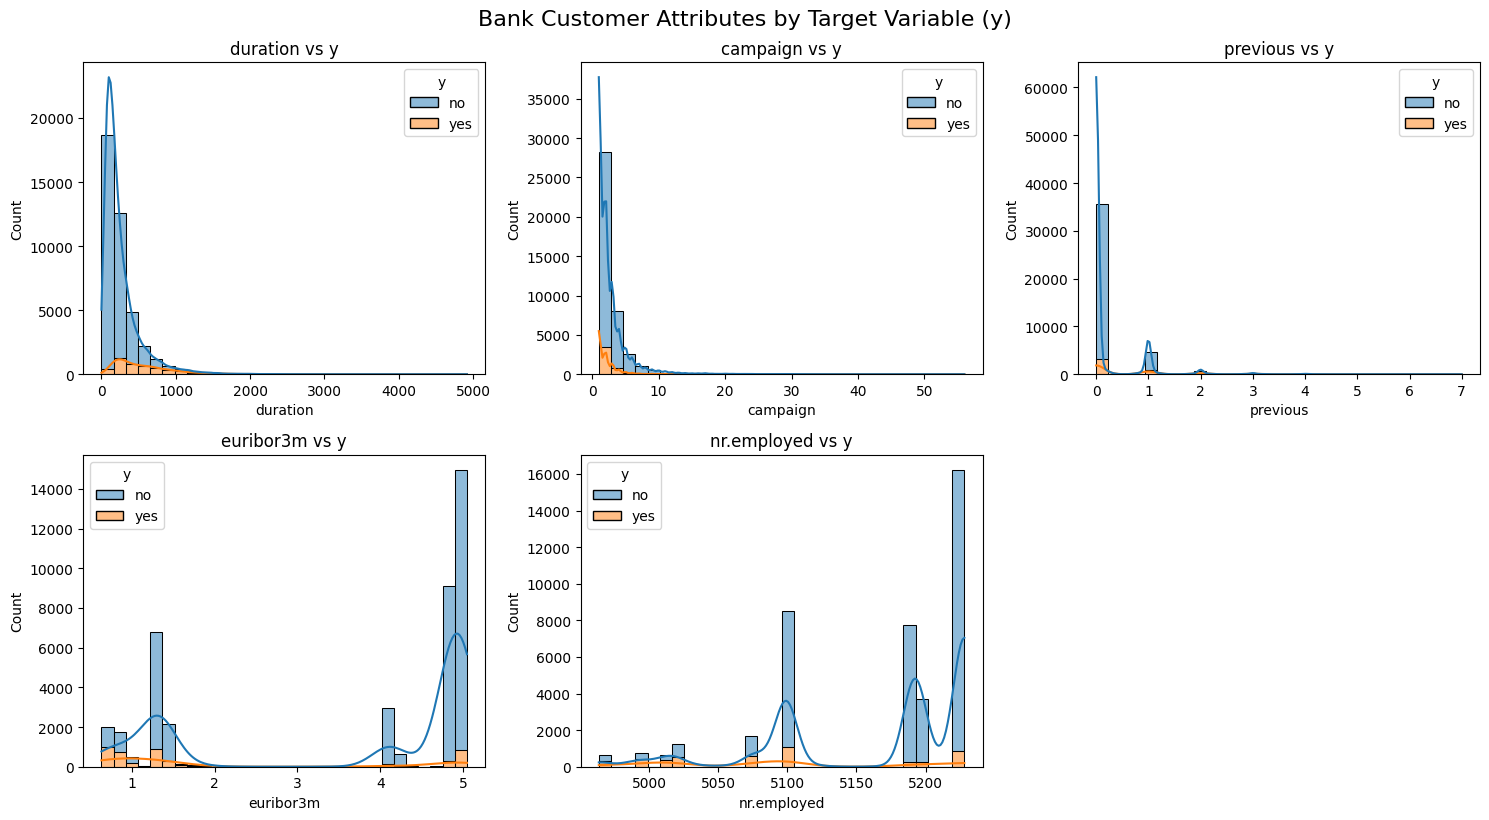

In [ ]:
# 분석 대상 컬럼과 타겟 변수
customer_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
target = 'y'

# 서브플롯 설정
n_cols = 3
n_rows = -(-len(cols) // n_cols)  # 올림 계산
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)

    if pd.api.types.is_numeric_dtype(df[col]):
        # 수치형 변수: 히스토그램
        sns.histplot(data=df, x=col, hue=target, bins=30, kde=True, multiple="stack")
    else:
        # 범주형 변수: 카운트플롯
        sns.countplot(data=df, x=col, hue=target)
        plt.xticks(rotation=30)

    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.suptitle('Bank Customer Attributes by Target Variable (y)', fontsize=16, y=1.02)
plt.show()

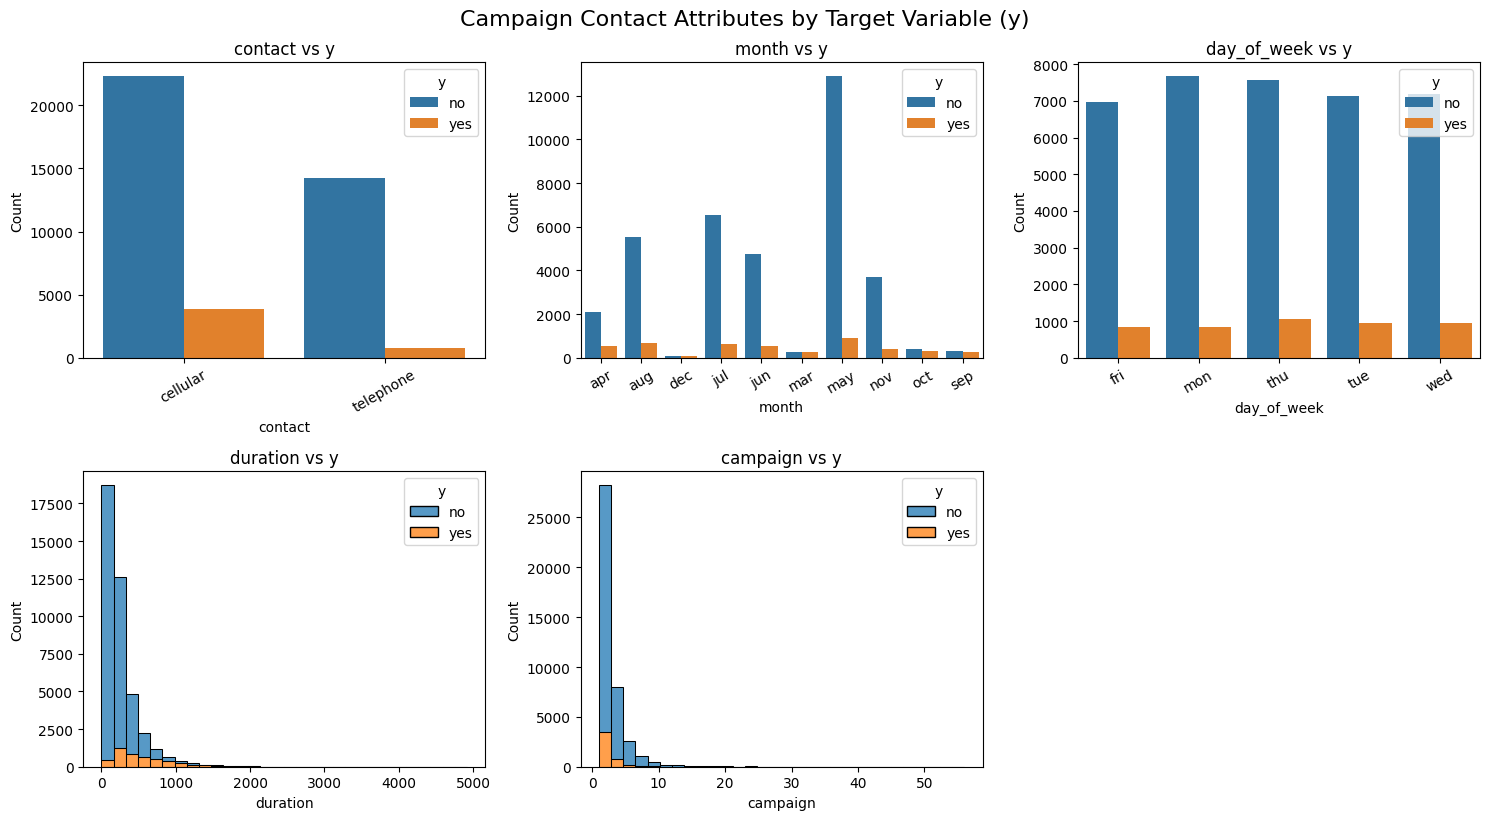

In [ ]:
# 연락 관련 컬럼
campaign_cols = ['contact', 'month', 'day_of_week', 'duration', 'campaign']
target = 'y'

# 서브플롯 설정
n_cols = 3
n_rows = -(-len(campaign_cols) // n_cols)
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(campaign_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    if pd.api.types.is_numeric_dtype(df[col]):
        # 수치형 변수: 히스토그램
        sns.histplot(data=df, x=col, hue=target, bins=30, kde=False, multiple="stack")
    else:
        # 범주형 변수: 카운트플롯
        sns.countplot(data=df, x=col, hue=target, order=sorted(df[col].unique()))
        plt.xticks(rotation=30)

    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.suptitle('Campaign Contact Attributes by Target Variable (y)', fontsize=16, y=1.02)
plt.show()


### 2.2 상관관계 히트맵
---
- 차트 유형: heatmap()
- 데이터: 상관계수

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,outlier_flag,contacted_before,emp_rate_bin,cons_price_qcut
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,1,No,Positive,Q3
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,1,No,Positive,Q3
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,1,No,Positive,Q3
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,1,No,Positive,Q3
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,1,No,Positive,Q3


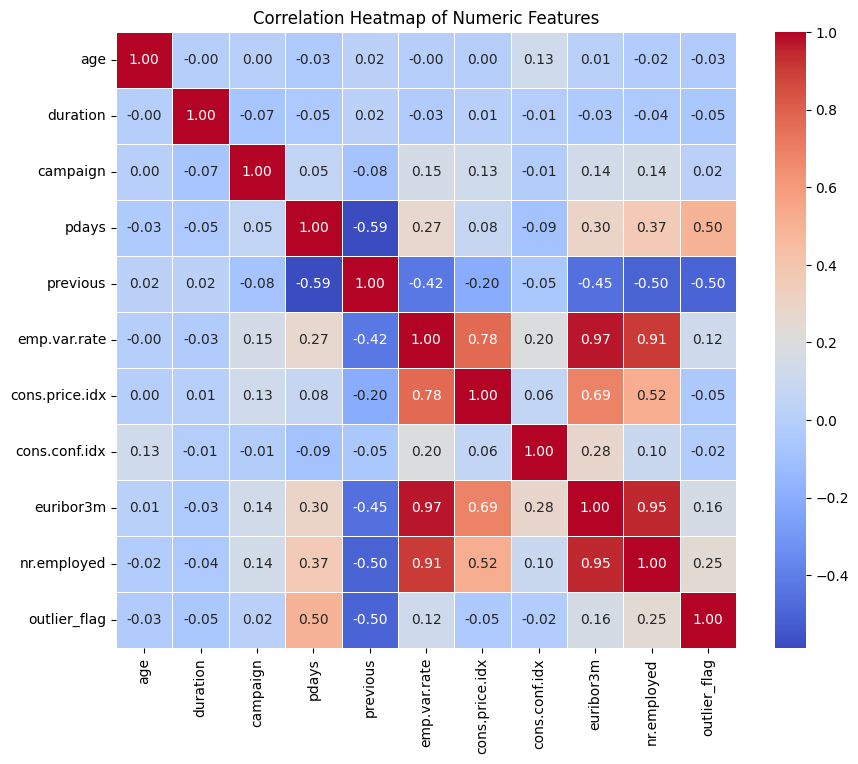

In [ ]:
# 수치형 변수만 추출하여 상관관계 행렬 계산
corr_matrix = df.select_dtypes(include='number').corr()

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

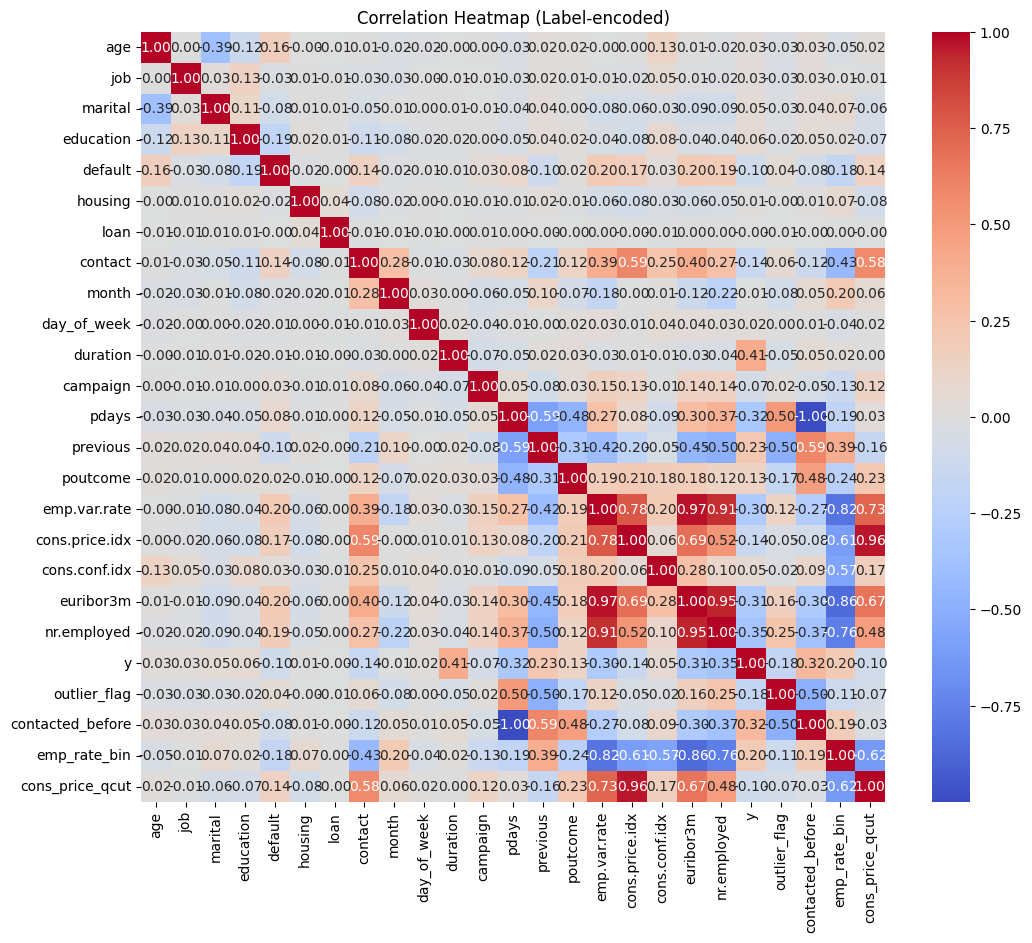

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# 상관계수 행렬 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Label-encoded)')
plt.show()

### 2.3 월별 평균 통화시간 추이 및 가입률
---
- 차트 유형: lineplot()
- x축: `month`
- y축: `duration`

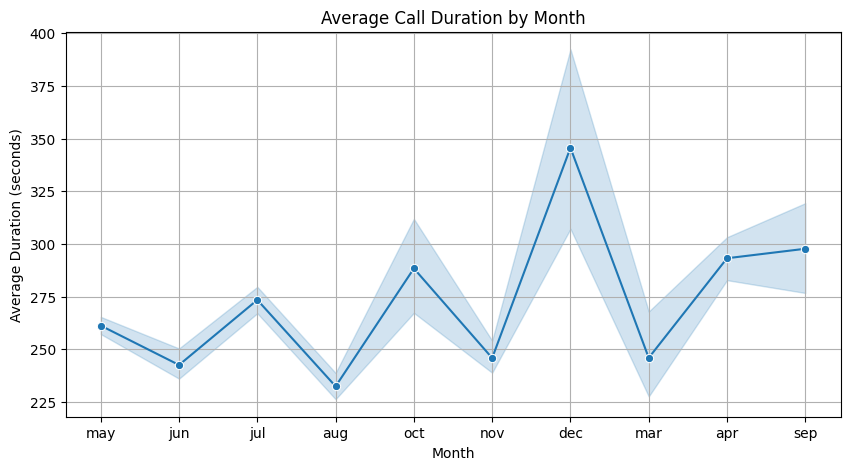

In [ ]:
# 선 그래프 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x = 'month', y= 'duration', marker='o')
plt.title('Average Call Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Duration (seconds)')
plt.grid(True)
plt.show()

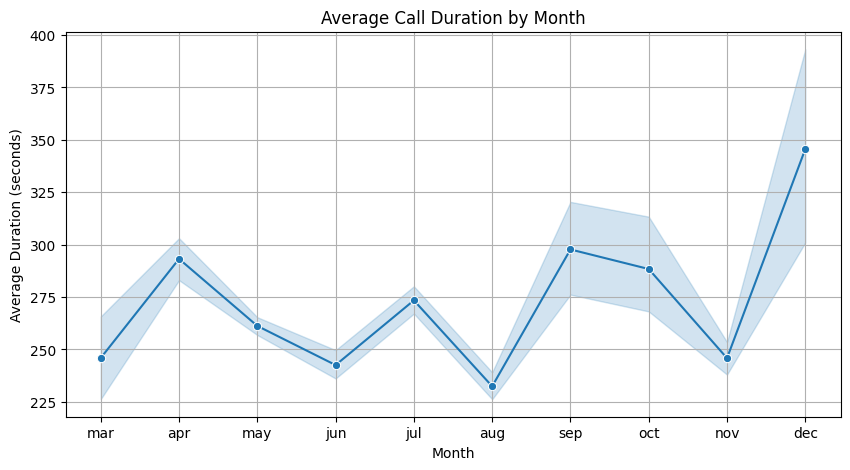

In [ ]:
# 월 순서 고정
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# 선 그래프 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x = 'month', y= 'duration', marker='o')
plt.title('Average Call Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Duration (seconds)')
plt.grid(True)
plt.show()

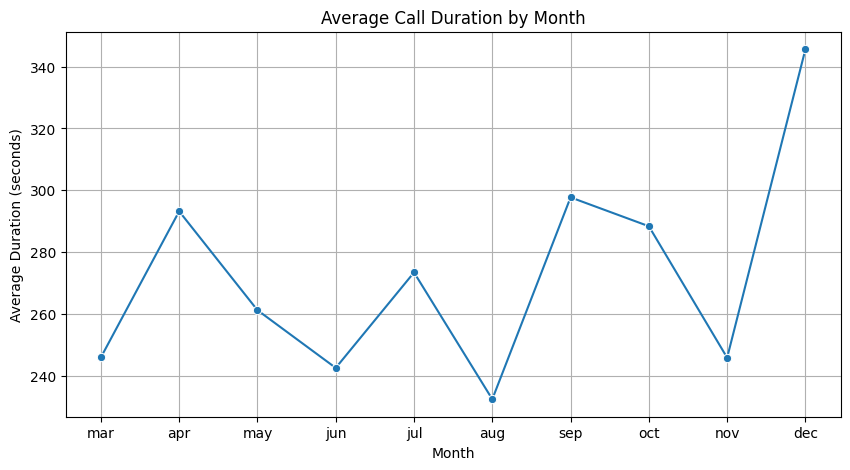

In [ ]:
# 선 그래프 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x = 'month', y= 'duration', marker='o', errorbar=None)
plt.title('Average Call Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Duration (seconds)')
plt.grid(True)
plt.show()

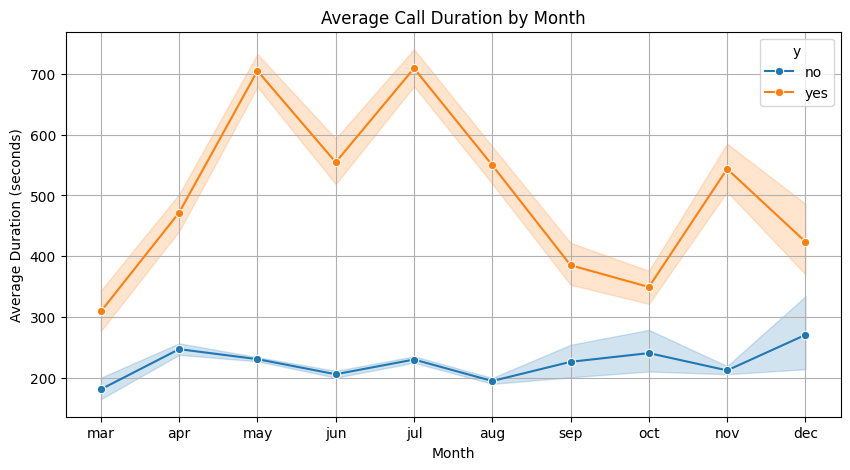

In [ ]:
# 선 그래프 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x = 'month', y= 'duration',
             hue = 'y', marker='o')#
plt.title('Average Call Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Duration (seconds)')
plt.grid(True)
plt.show()

### 2.4 campaign 횟수에 따른 가입률
---

In [ ]:
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})
campaign_success_rate = df.groupby('campaign')['y_encoded'].mean()
campaign_success_rate

,y_encoded
campaign,
1,0.130371
2,0.114570
3,0.107471
4,0.093927
5,0.075047
6,0.076609
7,0.060413
8,0.042500
9,0.060071


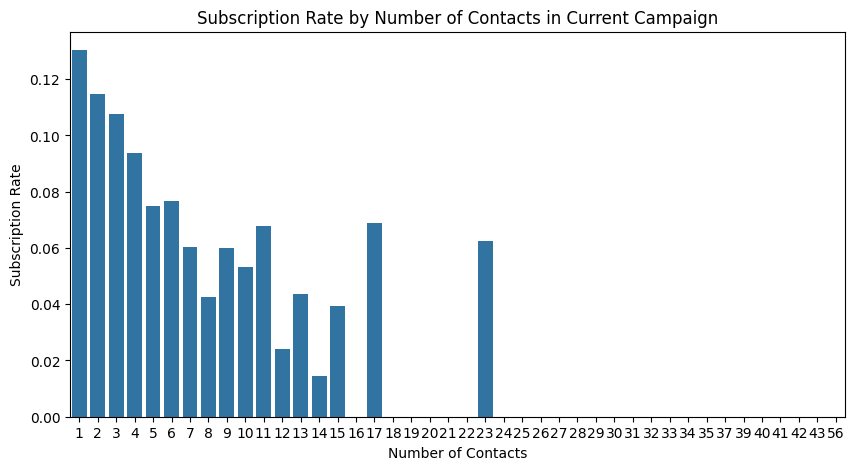

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=campaign_success_rate.index,
             y=campaign_success_rate.values)
plt.title('Subscription Rate by Number of Contacts in Current Campaign')
plt.xlabel('Number of Contacts')
plt.ylabel('Subscription Rate')
plt.show()

campaign 횟수가 많아질수록 가입률이 낮아지는 경향이 나타납니다.

### 2.5 education 별 가입 비율
---

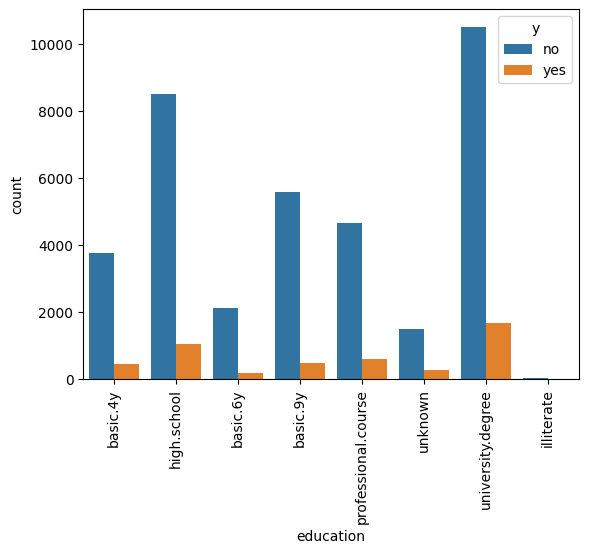

In [ ]:
# education 별 가입 비율
sns.countplot(data=df, x='education', hue='y')
plt.xticks(rotation=90)
plt.show()

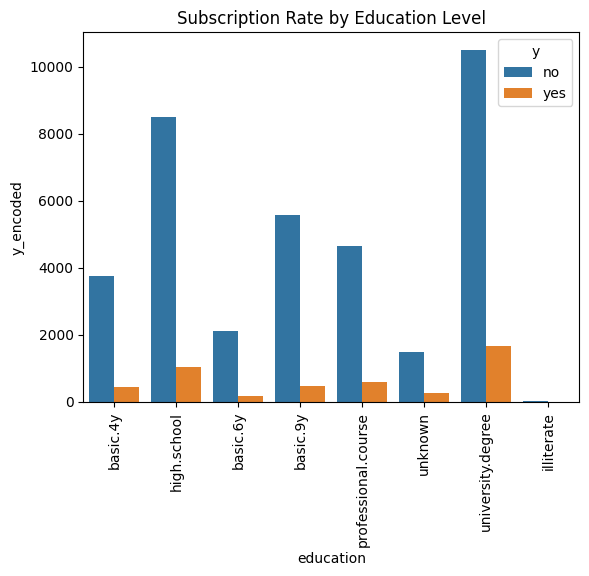

In [ ]:
# education 별 가입 비율
sns.barplot(data=df, x='education', y='y_encoded', estimator="size", hue = "y")
plt.title("Subscription Rate by Education Level")
plt.xticks(rotation=90)
plt.show()